# Modelo Predictivo: Clasificación de Violencia Intrafamiliar predominantemente
Este cuaderno implementa el ensamblado de datos y 3 algoritmos de Machine Learning (Árboles, Bosques y Regresión Logística) acorde a los lineamientos del proyecto para responder a la viabilidad de la variable respuesta.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata, re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, precision_score, recall_score)

sns.set_theme(style='whitegrid')
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

In [5]:
# ============================================================
# DATASET ENFOQUE ORIGINAL: Predecir tipo de VIF predominante
# (Física / Psicológica / Patrimonial) basado en características
# sociodemográficas y tasa de divorcios.
# ============================================================

def slugify(v):
    if not isinstance(v, str): return ''
    n = unicodedata.normalize('NFKD', v)
    s = "".join(ch for ch in n if not unicodedata.combining(ch)).lower()
    return re.sub(r'[^a-z0-9]+', '_', s).strip('_')

print("1. Cargando datasets...")
df_panel    = pd.read_csv('../Datos/Procesados/panel_departamento_anio.csv')
df_hogares  = pd.read_csv('../Datos/Poblacion/hogares_decisiones.csv',
                          encoding='latin-1', thousands=',')
df_economia = pd.read_csv('../Datos/Poblacion/economia_empleo.csv',
                          encoding='latin-1', thousands=',')
df_civil    = pd.read_csv('../Datos/Poblacion/estado_civil.csv')
df_edu      = pd.read_csv('../Datos/Poblacion/nivel_educativo.csv')
df_pob      = pd.read_csv('../Datos/Poblacion/poblacion_total.csv')

print("2. Normalizando claves geográficas...")
for df in [df_panel, df_hogares, df_economia, df_civil, df_edu, df_pob]:
    for col in ['departamento', 'Departamento']:
        if col in df.columns:
            df['key'] = df[col].apply(slugify)
            break

print("3. Feature engineering censal (datos estáticos 2018)...")

# Educación
sup = df_edu['Superior_Licenciatura'] + df_edu.get('Superior_Maestria_Doc', 0)
df_edu['pct_educacion_superior'] = (sup / df_edu['Poblacion_4_mas']) * 100

# Estado civil
df_civil['pct_uniones_hecho'] = (df_civil['Unido'] / df_civil['Población_10_mas']) * 100
df_civil['pct_casados']       = (df_civil['Casado'] / df_civil['Población_10_mas']) * 100

# Hogares (decisiones)
df_hogares['pct_decision_mujer']  = (df_hogares['decision_mujer']  / df_hogares['total_de_hogares']) * 100
df_hogares['pct_decision_hombre'] = (df_hogares['decision_hombre'] / df_hogares['total_de_hogares']) * 100

# Economía
pea_total = df_economia['pea_ocupados'] + df_economia['pea_cesantes'] + df_economia['pea_aspirantes']
df_economia['tasa_desempleo']        = ((df_economia['pea_cesantes'] + df_economia['pea_aspirantes']) / pea_total) * 100
df_economia['tasa_quehaceres_hogar'] = (df_economia['pei_quehaceres_hogar'] / df_economia['poblacion_15_mas']) * 100

# Población (para tasas)
df_pob = df_pob.rename(columns={'Población total censada': 'poblacion_total'})

print("4. Filtrando panel histórico 2013-2023...")
df = df_panel[(df_panel['anio'] >= 2013) & (df_panel['anio'] <= 2023)].copy()

print("5. Consolidando tipos de VIF (sumando combinaciones mixtas)...")
cols_fisica = [
    'vif_tipo_fisica', 'vif_tipo_fisica_patrimonial',
    'vif_tipo_fisica_psicologica', 'vif_tipo_fisica_psicologica_patrimonial',
    'vif_tipo_fisica_psicologica_sexual', 'vif_tipo_fisica_psicologica_sexual_patrimonial',
    'vif_tipo_fisica_sexual', 'vif_tipo_fisica_sexual_patrimonial'
]
cols_psicologica = [
    'vif_tipo_psicologica', 'vif_tipo_fisica_psicologica',
    'vif_tipo_fisica_psicologica_patrimonial', 'vif_tipo_fisica_psicologica_sexual',
    'vif_tipo_fisica_psicologica_sexual_patrimonial', 'vif_tipo_psicologica_patrimonial',
    'vif_tipo_psicologica_sexual', 'vif_tipo_psicologica_sexual_patrimonial'
]
cols_patrimonial = [
    'vif_tipo_patrimonial', 'vif_tipo_fisica_patrimonial',
    'vif_tipo_fisica_psicologica_patrimonial', 'vif_tipo_fisica_psicologica_sexual_patrimonial',
    'vif_tipo_fisica_sexual_patrimonial', 'vif_tipo_psicologica_patrimonial',
    'vif_tipo_psicologica_sexual_patrimonial', 'vif_tipo_sexual_patrimonial'
]

df['vif_fisica_consolidada']      = df[cols_fisica].fillna(0).sum(axis=1)
df['vif_psicologica_consolidada'] = df[cols_psicologica].fillna(0).sum(axis=1)
df['vif_patrimonial_consolidada'] = df[cols_patrimonial].fillna(0).sum(axis=1)

print("6. Merge con datos censales...")
df_master = df.merge(df_pob[['key', 'poblacion_total']], on='key', how='left')
df_master = df_master.merge(df_hogares[['key', 'pct_decision_mujer', 'pct_decision_hombre']], on='key', how='left')
df_master = df_master.merge(df_economia[['key', 'tasa_desempleo', 'tasa_quehaceres_hogar']], on='key', how='left')
df_master = df_master.merge(df_civil[['key', 'pct_uniones_hecho', 'pct_casados']], on='key', how='left')
df_master = df_master.merge(df_edu[['key', 'pct_educacion_superior']], on='key', how='left')

print("7. Calculando tasas por 10k habitantes...")
df_master['tasa_fisica']        = (df_master['vif_fisica_consolidada']      / df_master['poblacion_total']) * 10000
df_master['tasa_psicologica']   = (df_master['vif_psicologica_consolidada'] / df_master['poblacion_total']) * 10000
df_master['tasa_patrimonial']   = (df_master['vif_patrimonial_consolidada'] / df_master['poblacion_total']) * 10000
df_master['tasa_divorcios_10k'] = (df_master['divorcios_total']             / df_master['poblacion_total']) * 10000

print("8. Creando TARGET: tipo de VIF predominante...")
tipo_cols = ['tasa_fisica', 'tasa_psicologica', 'tasa_patrimonial']
df_master['vif_predominante'] = (
    df_master[tipo_cols]
    .idxmax(axis=1)
    .str.replace('tasa_', '')
    .str.capitalize()
)

# Limpieza final
df_master = df_master.dropna(subset=['pct_uniones_hecho', 'pct_educacion_superior',
                                      'tasa_desempleo', 'pct_decision_mujer'])

print(f"\n✅ Dataset final: {df_master.shape}")
print("\n=== DISTRIBUCIÓN DEL TARGET ===")
print(df_master['vif_predominante'].value_counts())
print(f"\nEn porcentaje:")
print((df_master['vif_predominante'].value_counts(normalize=True) * 100).round(1))

# Vista
print("\n=== PRIMERAS FILAS ===")
display(df_master[['departamento', 'anio',
                   'tasa_fisica', 'tasa_psicologica', 'tasa_patrimonial',
                   'tasa_divorcios_10k', 'vif_predominante']].head(10))

# ============================================================
# EXPORTAR DATASET A CSV
# ============================================================
columnas_finales = [
    'departamento', 'anio', 'poblacion_total',
    # Consolidados absolutos
    'vif_fisica_consolidada', 'vif_psicologica_consolidada', 'vif_patrimonial_consolidada',
    # Tasas por 10k
    'tasa_fisica', 'tasa_psicologica', 'tasa_patrimonial',
    'tasa_divorcios_10k',
    # Predictores sociodemográficos
    'pct_educacion_superior', 'pct_uniones_hecho', 'pct_casados',
    'pct_decision_mujer', 'pct_decision_hombre',
    'tasa_desempleo', 'tasa_quehaceres_hogar',
    # TARGET
    'vif_predominante'
]

df_export = df_master[columnas_finales].copy()
ruta_export = '../Datos/Procesados/dataset_enfoque_original.csv'
df_export.to_csv(ruta_export, index=False, encoding='utf-8-sig')
print(f"\n✅ Archivo exportado: {ruta_export}")
print(f"   Dimensiones: {df_export.shape}")

1. Cargando datasets...
2. Normalizando claves geográficas...
3. Feature engineering censal (datos estáticos 2018)...
4. Filtrando panel histórico 2013-2023...
5. Consolidando tipos de VIF (sumando combinaciones mixtas)...
6. Merge con datos censales...
7. Calculando tasas por 10k habitantes...
8. Creando TARGET: tipo de VIF predominante...

✅ Dataset final: (242, 137)

=== DISTRIBUCIÓN DEL TARGET ===
vif_predominante
Psicologica    239
Fisica           3
Name: count, dtype: int64

En porcentaje:
vif_predominante
Psicologica    98.8
Fisica          1.2
Name: proportion, dtype: float64

=== PRIMERAS FILAS ===


,departamento,anio,tasa_fisica,tasa_psicologica,tasa_patrimonial,tasa_divorcios_10k,vif_predominante
0,Alta Verapaz,2013,16.024190,23.085698,3.053402,0.979393,Psicologica
1,Baja Verapaz,2013,22.706327,34.760715,5.543015,3.272382,Psicologica
2,Chimaltenango,2013,15.606324,26.243309,5.570207,1.039339,Psicologica
3,Chiquimula,2013,7.324189,9.203422,1.060080,2.096067,Psicologica
4,El Progreso,2013,33.799085,58.086870,10.077449,4.076272,Psicologica
5,Escuintla,2013,7.528837,8.865478,0.613764,2.086797,Psicologica
6,Guatemala,2013,11.180462,19.395830,3.528927,5.979939,Psicologica
7,Huehuetenango,2013,12.078564,12.855897,3.297260,1.067766,Psicologica
8,Izabal,2013,14.583252,19.843989,4.991583,3.009631,Psicologica
9,Jalapa,2013,12.131003,20.791840,1.224765,2.857784,Psicologica



✅ Archivo exportado: ../Datos/Procesados/dataset_enfoque_original.csv
   Dimensiones: (242, 18)


In [7]:
# ============================================================
# VARIABLES PREDICTORAS (X) y TARGET (y)
# ============================================================
features = [
    'tasa_divorcios_10k',       # único predictor temporal
    'pct_educacion_superior',   # censo 2018
    'pct_uniones_hecho',
    'pct_casados',
    'pct_decision_mujer',
    'pct_decision_hombre',
    'tasa_desempleo',
    'tasa_quehaceres_hogar'
]

# Rellenar nulos marginales
df_master[features] = df_master[features].fillna(df_master[features].median())

# Encoding del target
le = LabelEncoder()
df_master['Target'] = le.fit_transform(df_master['vif_predominante'])
clases_target = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Clases del target:\n{clases_target}\n")

# Split + Scaling
X = df_master[features]
y = df_master['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Entrenamiento: {X_train_scaled.shape}")
print(f"Prueba:        {X_test_scaled.shape}")
print("\n✅ Pipeline listo para modelado.")

Clases del target:
{'Fisica': np.int64(0), 'Psicologica': np.int64(1)}

Entrenamiento: (181, 8)
Prueba:        (61, 8)

✅ Pipeline listo para modelado.


## 2. Modelo 1: Árboles de Decisión (Interpretabilidad Visual)

✅ Mejores parámetros: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 5}
✅ Mejor F1 (CV): 0.7595

MÉTRICAS GLOBALES — ÁRBOL DE DECISIÓN
Accuracy:          0.9836
F1 Score (macro):  0.8291
F1 Score (weight): 0.9863
Precision (macro): 0.7500
Recall (macro):    0.9917

REPORTE POR CLASE
              precision    recall  f1-score   support

      Fisica       0.50      1.00      0.67         1
 Psicologica       1.00      0.98      0.99        60

    accuracy                           0.98        61
   macro avg       0.75      0.99      0.83        61
weighted avg       0.99      0.98      0.99        61



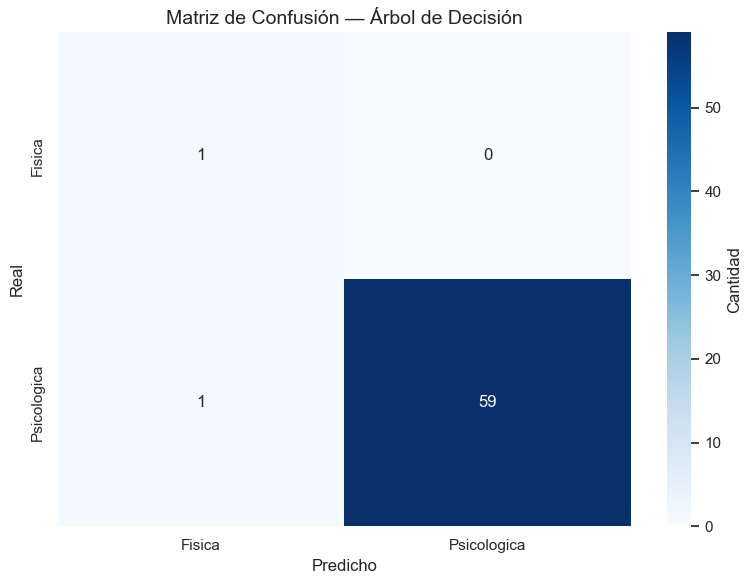

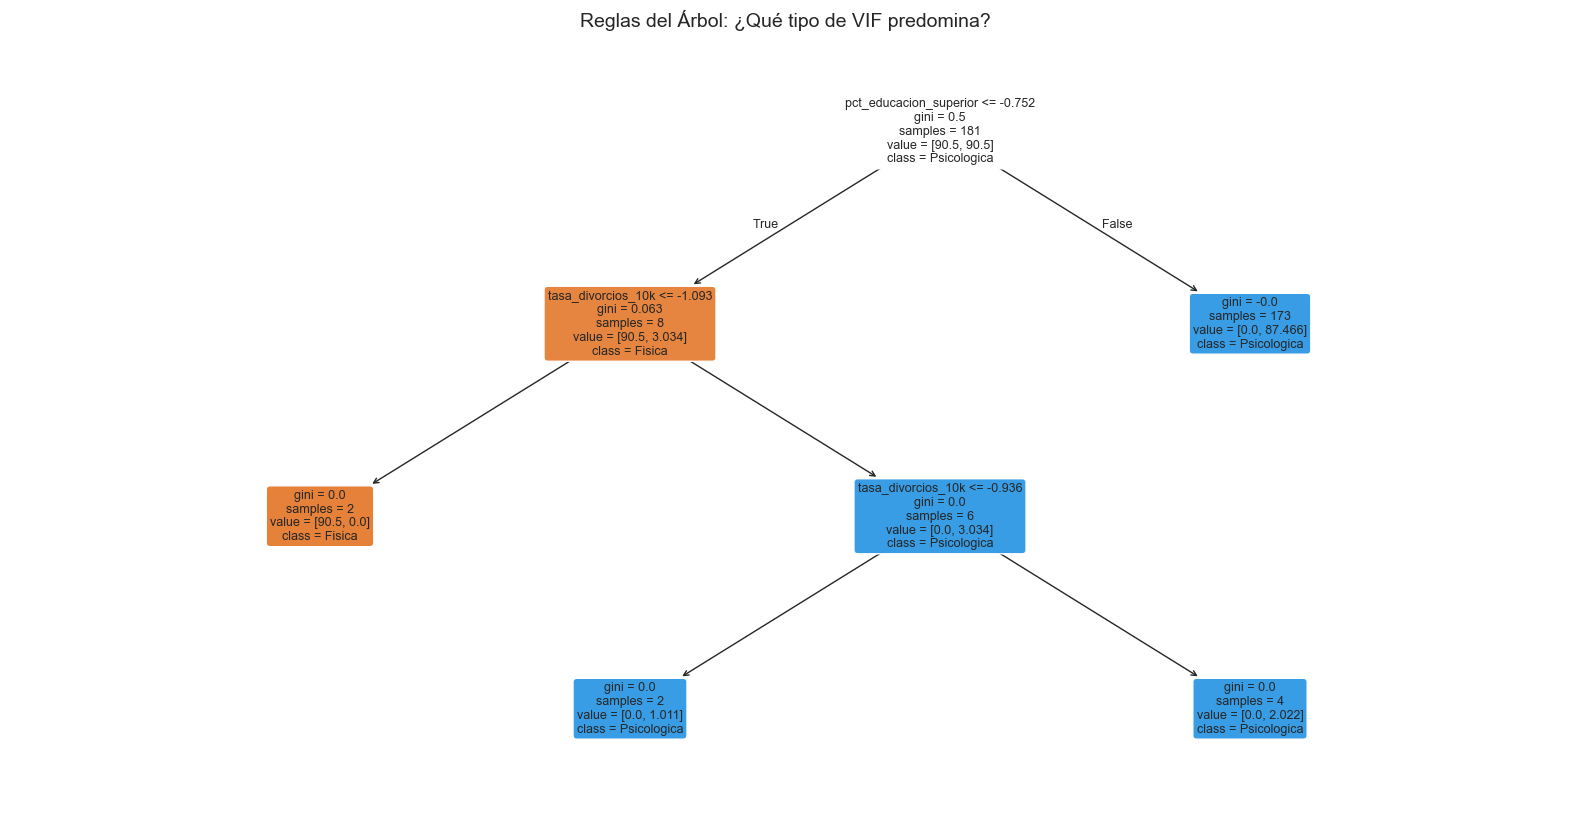

In [8]:
# ============================================================
# TUNING: ÁRBOL DE DECISIÓN
# ============================================================
param_grid_dt = {
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_split': [5, 10, 15, 20],
    'min_samples_leaf': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid_dt,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
grid_dt.fit(X_train_scaled, y_train)

print(f"✅ Mejores parámetros: {grid_dt.best_params_}")
print(f"✅ Mejor F1 (CV): {grid_dt.best_score_:.4f}\n")

# Usar el mejor modelo
dt = grid_dt.best_estimator_
y_pred_dt = dt.predict(X_test_scaled)

# ============================================================
# MÉTRICAS GLOBALES
# ============================================================
print("=" * 60)
print("MÉTRICAS GLOBALES — ÁRBOL DE DECISIÓN")
print("=" * 60)
print(f"Accuracy:          {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"F1 Score (macro):  {f1_score(y_test, y_pred_dt, average='macro'):.4f}")
print(f"F1 Score (weight): {f1_score(y_test, y_pred_dt, average='weighted'):.4f}")
print(f"Precision (macro): {precision_score(y_test, y_pred_dt, average='macro', zero_division=0):.4f}")
print(f"Recall (macro):    {recall_score(y_test, y_pred_dt, average='macro'):.4f}")

# ============================================================
# REPORTE POR CLASE
# ============================================================
print("\n" + "=" * 60)
print("REPORTE POR CLASE")
print("=" * 60)
print(classification_report(y_test, y_pred_dt, target_names=le.classes_, zero_division=0))

# ============================================================
# MATRIZ DE CONFUSIÓN
# ============================================================
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Cantidad'})
plt.title('Matriz de Confusión — Árbol de Decisión', fontsize=14)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

# ============================================================
# VISUALIZAR EL ÁRBOL
# ============================================================
plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=features, class_names=le.classes_,
          filled=True, rounded=True, fontsize=9)
plt.title("Reglas del Árbol: ¿Qué tipo de VIF predomina?", fontsize=14)
plt.show()

## 3. Modelo 2: Random Forest (Solidez y Prevención de Overfitting)

✅ Mejores parámetros: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
✅ Mejor F1 (CV): 0.6928

MÉTRICAS GLOBALES — RANDOM FOREST
Accuracy:          0.9836
F1 Score (macro):  0.8291
F1 Score (weight): 0.9863
Precision (macro): 0.7500
Recall (macro):    0.9917

REPORTE POR CLASE
              precision    recall  f1-score   support

      Fisica       0.50      1.00      0.67         1
 Psicologica       1.00      0.98      0.99        60

    accuracy                           0.98        61
   macro avg       0.75      0.99      0.83        61
weighted avg       0.99      0.98      0.99        61



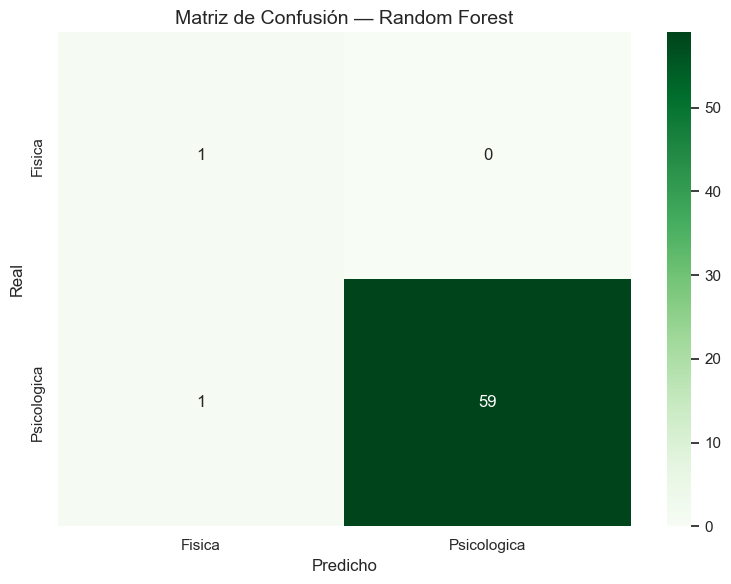

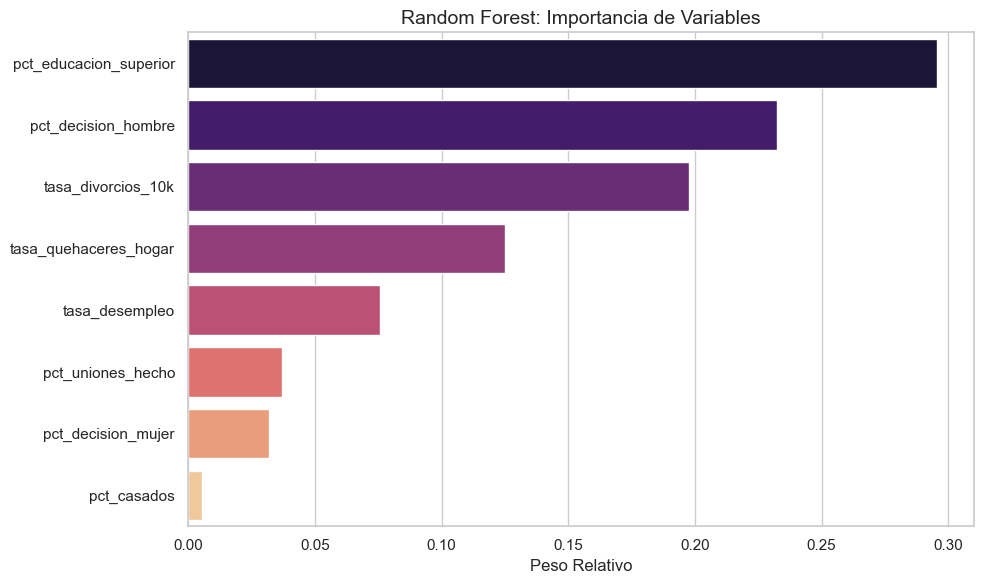


Ranking de importancia:
              Variable  Importancia
pct_educacion_superior       0.2953
   pct_decision_hombre       0.2325
    tasa_divorcios_10k       0.1975
 tasa_quehaceres_hogar       0.1250
        tasa_desempleo       0.0756
     pct_uniones_hecho       0.0369
    pct_decision_mujer       0.0318
           pct_casados       0.0054


In [9]:
# ============================================================
# TUNING: RANDOM FOREST
# ============================================================
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7, 10],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid_rf,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
grid_rf.fit(X_train_scaled, y_train)

print(f"✅ Mejores parámetros: {grid_rf.best_params_}")
print(f"✅ Mejor F1 (CV): {grid_rf.best_score_:.4f}\n")

rf = grid_rf.best_estimator_
y_pred_rf = rf.predict(X_test_scaled)

# ============================================================
# MÉTRICAS GLOBALES
# ============================================================
print("=" * 60)
print("MÉTRICAS GLOBALES — RANDOM FOREST")
print("=" * 60)
print(f"Accuracy:          {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score (macro):  {f1_score(y_test, y_pred_rf, average='macro'):.4f}")
print(f"F1 Score (weight): {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"Precision (macro): {precision_score(y_test, y_pred_rf, average='macro', zero_division=0):.4f}")
print(f"Recall (macro):    {recall_score(y_test, y_pred_rf, average='macro'):.4f}")

print("\n" + "=" * 60)
print("REPORTE POR CLASE")
print("=" * 60)
print(classification_report(y_test, y_pred_rf, target_names=le.classes_, zero_division=0))

# ============================================================
# MATRIZ DE CONFUSIÓN
# ============================================================
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusión — Random Forest', fontsize=14)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

# ============================================================
# IMPORTANCIA DE VARIABLES
# ============================================================
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=np.array(features)[indices], palette="magma")
plt.title("Random Forest: Importancia de Variables", fontsize=14)
plt.xlabel("Peso Relativo")
plt.tight_layout()
plt.show()

# Tabla de importancias
df_imp = pd.DataFrame({
    'Variable': np.array(features)[indices],
    'Importancia': importances[indices]
}).round(4)
print("\nRanking de importancia:")
print(df_imp.to_string(index=False))

## 4. Modelo 3: Regresión Logística Múltiple (Impacto Probabilístico)

✅ Mejores parámetros: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
✅ Mejor F1 (CV): 0.7595

MÉTRICAS GLOBALES — REGRESIÓN LOGÍSTICA
Accuracy:          0.9672
F1 Score (macro):  0.7415
F1 Score (weight): 0.9751
Precision (macro): 0.6667
Recall (macro):    0.9833

REPORTE POR CLASE
              precision    recall  f1-score   support

      Fisica       0.33      1.00      0.50         1
 Psicologica       1.00      0.97      0.98        60

    accuracy                           0.97        61
   macro avg       0.67      0.98      0.74        61
weighted avg       0.99      0.97      0.98        61



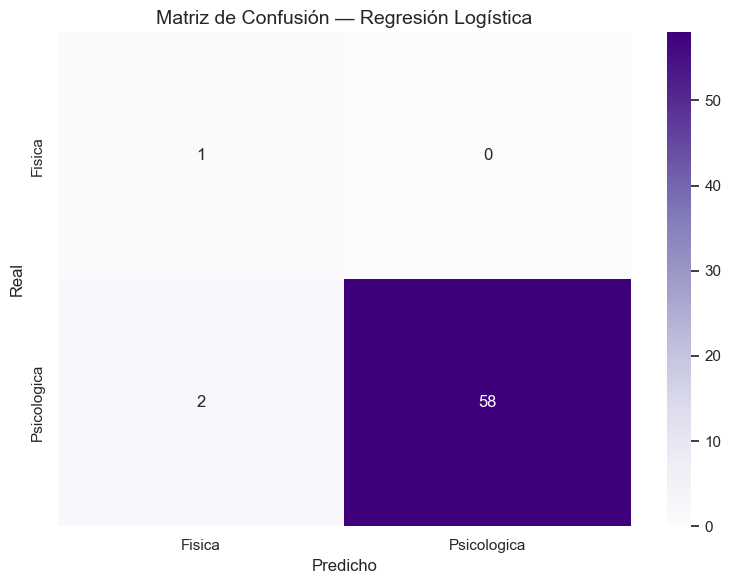

Shape de coeficientes: (1, 8)
Número de clases en y_train: 2
Clases del encoder: ['Fisica', 'Psicologica']

⚠️  El modelo entrenó con solo 1 vector de coeficientes.
Esto ocurre cuando el target está extremadamente desbalanceado.



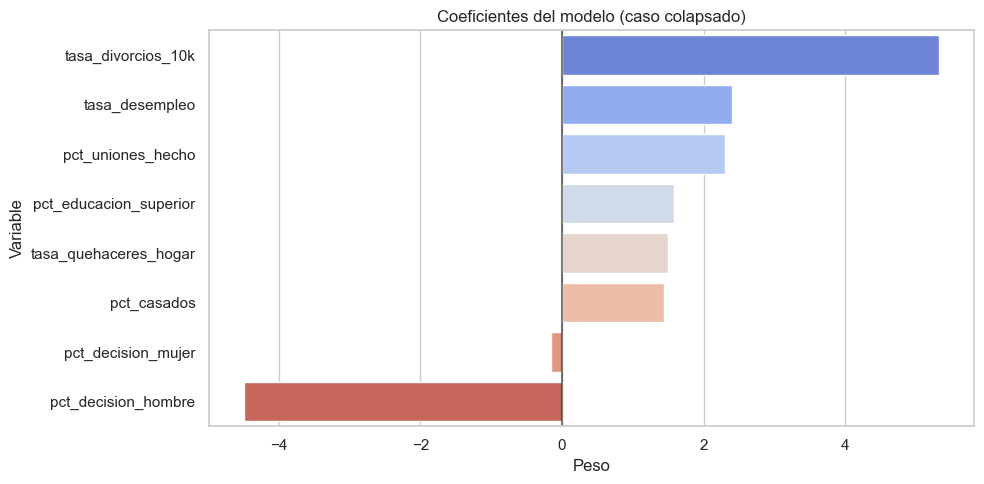


 Tabla de coeficientes:
 Clase  tasa_divorcios_10k  pct_educacion_superior  pct_uniones_hecho  pct_casados  pct_decision_mujer  pct_decision_hombre  tasa_desempleo  tasa_quehaceres_hogar
Fisica              5.3306                  1.5862             2.3043       1.4468             -0.1536              -4.4999          2.4095                 1.5022


In [13]:
# ============================================================
# TUNING: REGRESIÓN LOGÍSTICA
# ============================================================
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    param_grid_lr,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
grid_lr.fit(X_train_scaled, y_train)

print(f"✅ Mejores parámetros: {grid_lr.best_params_}")
print(f"✅ Mejor F1 (CV): {grid_lr.best_score_:.4f}\n")

log_reg = grid_lr.best_estimator_
y_pred_lr = log_reg.predict(X_test_scaled)

# ============================================================
# MÉTRICAS GLOBALES
# ============================================================
print("=" * 60)
print("MÉTRICAS GLOBALES — REGRESIÓN LOGÍSTICA")
print("=" * 60)
print(f"Accuracy:          {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score (macro):  {f1_score(y_test, y_pred_lr, average='macro'):.4f}")
print(f"F1 Score (weight): {f1_score(y_test, y_pred_lr, average='weighted'):.4f}")
print(f"Precision (macro): {precision_score(y_test, y_pred_lr, average='macro', zero_division=0):.4f}")
print(f"Recall (macro):    {recall_score(y_test, y_pred_lr, average='macro'):.4f}")

print("\n" + "=" * 60)
print("REPORTE POR CLASE")
print("=" * 60)
print(classification_report(y_test, y_pred_lr, target_names=le.classes_, zero_division=0))

# ============================================================
# MATRIZ DE CONFUSIÓN
# ============================================================
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusión — Regresión Logística', fontsize=14)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

# ============================================================
# COEFICIENTES POR CLASE
# ============================================================
coef = log_reg.coef_
print(f"Shape de coeficientes: {coef.shape}")
print(f"Número de clases en y_train: {len(np.unique(y_train))}")
print(f"Clases del encoder: {list(le.classes_)}\n")

# Determinar qué clases están representadas en los coeficientes
if coef.shape[0] == 1:
    # Caso binario o una sola clase efectiva
    print("⚠️  El modelo entrenó con solo 1 vector de coeficientes.")
    print("Esto ocurre cuando el target está extremadamente desbalanceado.\n")
    
    fig, ax = plt.subplots(figsize=(10, 5))
    df_coef = pd.DataFrame({'Variable': features, 'Peso': coef[0]})
    df_coef = df_coef.sort_values(by='Peso', ascending=False)
    sns.barplot(data=df_coef, x='Peso', y='Variable', palette="coolwarm", ax=ax)
    ax.axvline(0, color='black', alpha=0.5)
    ax.set_title("Coeficientes del modelo (caso colapsado)")
    plt.tight_layout()
    plt.show()
else:
    # Caso multiclase normal
    n_clases_coef = coef.shape[0]
    clases_mostrar = le.classes_[:n_clases_coef]
    
    fig, axes = plt.subplots(1, n_clases_coef, figsize=(6*n_clases_coef, 5))
    if n_clases_coef == 1:
        axes = [axes]

    for i, (ax, clase) in enumerate(zip(axes, clases_mostrar)):
        df_coef = pd.DataFrame({'Variable': features, 'Peso': coef[i]})
        df_coef = df_coef.sort_values(by='Peso', ascending=False)
        sns.barplot(data=df_coef, x='Peso', y='Variable', palette="coolwarm", ax=ax)
        ax.axvline(0, color='black', alpha=0.5)
        ax.set_title(f"Afinidad hacia '{clase}'")

    plt.tight_layout()
    plt.show()

print("\n Tabla de coeficientes:")
df_coef_full = pd.DataFrame(coef, columns=features)
df_coef_full.insert(0, 'Clase', le.classes_[:coef.shape[0]])
print(df_coef_full.round(4).to_string(index=False))

Comparativa con los modelos

COMPARATIVA DE MODELOS
             Modelo  Accuracy  F1 Macro  F1 Weighted  Precision Macro  Recall Macro
              Árbol    0.9836    0.8291       0.9863           0.7500        0.9917
      Random Forest    0.9836    0.8291       0.9863           0.7500        0.9917
Regresión Logística    0.9672    0.7415       0.9751           0.6667        0.9833


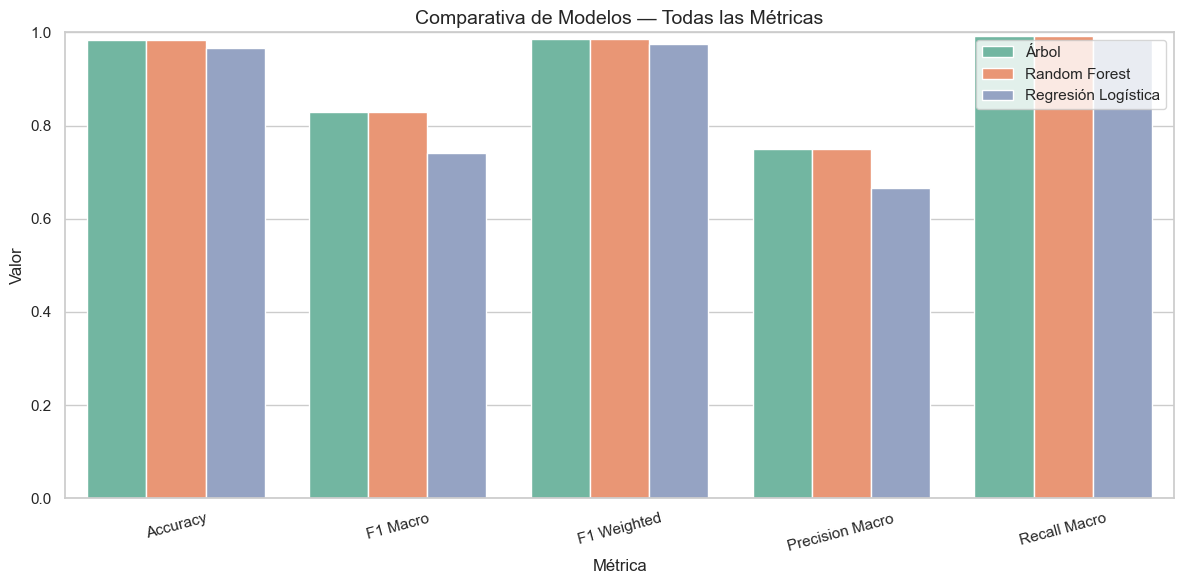

In [14]:
# ============================================================
# TABLA COMPARATIVA DE LOS 3 MODELOS
# ============================================================
resultados = pd.DataFrame({
    'Modelo': ['Árbol', 'Random Forest', 'Regresión Logística'],
    'Accuracy':        [accuracy_score(y_test, y_pred_dt),
                        accuracy_score(y_test, y_pred_rf),
                        accuracy_score(y_test, y_pred_lr)],
    'F1 Macro':        [f1_score(y_test, y_pred_dt, average='macro'),
                        f1_score(y_test, y_pred_rf, average='macro'),
                        f1_score(y_test, y_pred_lr, average='macro')],
    'F1 Weighted':     [f1_score(y_test, y_pred_dt, average='weighted'),
                        f1_score(y_test, y_pred_rf, average='weighted'),
                        f1_score(y_test, y_pred_lr, average='weighted')],
    'Precision Macro': [precision_score(y_test, y_pred_dt, average='macro', zero_division=0),
                        precision_score(y_test, y_pred_rf, average='macro', zero_division=0),
                        precision_score(y_test, y_pred_lr, average='macro', zero_division=0)],
    'Recall Macro':    [recall_score(y_test, y_pred_dt, average='macro'),
                        recall_score(y_test, y_pred_rf, average='macro'),
                        recall_score(y_test, y_pred_lr, average='macro')]
}).round(4)

print("=" * 70)
print("COMPARATIVA DE MODELOS")
print("=" * 70)
print(resultados.to_string(index=False))

# Gráfico comparativo
resultados_melt = resultados.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

plt.figure(figsize=(12, 6))
sns.barplot(data=resultados_melt, x='Métrica', y='Valor', hue='Modelo', palette='Set2')
plt.title('Comparativa de Modelos — Todas las Métricas', fontsize=14)
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

El enfoque original de predecir el tipo de violencia intrafamiliar predominante resultó técnicamente inviable debido al desbalance extremo del target: la violencia psicológica predomina en el 98.8% de los casos (239 de 242 departamento-año observados), la violencia física en el 1.2% (3 casos) y la patrimonial en el 0%. Aunque los modelos obtienen métricas de accuracy superiores al 96%, estas son engañosas porque un clasificador trivial que siempre prediga 'Psicológica' alcanzaría el mismo 98.8% sin aprender patrón alguno. La regresión logística colapsó explícitamente a un esquema binario por falta de datos en las clases minoritarias, y las matrices de confusión revelan que los modelos apenas detectan correctamente 1-2 casos de violencia física con precisiones del 33-50%. Estos resultados confirman que no existe variabilidad suficiente en el target para que los algoritmos aprendan distinciones significativas, lo cual motiva la reformulación de la variable respuesta.